In [17]:
import torch

from random import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [18]:
from itertools import combinations
from collections import Counter
from typing import List, Tuple, Iterable, Optional

def balanced_pair_split(k: int, labels: Optional[Iterable[str]] = None):
    """
    Generate a balanced partition of all unordered 2-combinations of k items into two groups.
    Returns (groupA, groupB, stats) where groupA/groupB are lists of tuple pairs (a,b) using labels,
    and stats is a dict with counts and checks.

    labels: optional iterable of k distinct labels (strings). If None, labels are "L0", "L1", ...
    """
    if k < 2:
        raise ValueError("k must be >= 2")

    # build labels
    if labels is None:
        labels = [f"L{i}" for i in range(k)]
    else:
        labels = list(labels)
        if len(labels) != k:
            raise ValueError("labels length must equal k")
    # round-robin construction
    # if k is odd -> n = k (odd), rounds = k-1 (even)
    # if k is even -> add dummy to make n = k+1 (odd), rounds = k (even)
    all_pairs = list(combinations(labels, 2))
    n_total_pairs = len(all_pairs)
    is_even = (n_total_pairs % 2 == 0)

    def split_pairs():
        idx = np.random.permutation(np.arange(n_total_pairs))  # shuffle for randomness
        half = n_total_pairs // 2
        groupA = [all_pairs[i] for i in idx[:half]]
        groupB = [all_pairs[i] for i in idx[half:]]
        return groupA, groupB
    def get_counts(group):
        cnt = Counter()
        for a, b in group:
            cnt[a] += 1
            cnt[b] += 1
        return cnt
    def is_balanced(groupA, groupB):
        cntA = get_counts(groupA)
        cntB = get_counts(groupB)
        for l in labels:
            if abs(cntA[l] - cntB[l]) > 1:
                return False
        return True

    max_search = 1000
    for attempt in range(max_search):
        groupA, groupB = split_pairs()
        if is_balanced(groupA, groupB):
            stats = {
                "k": k,
                "n_pairs": len(all_pairs),
                "n_groupA": len(groupA),
                "n_groupB": len(groupB),
                "counts_groupA": dict(get_counts(groupA)),
                "counts_groupB": dict(get_counts(groupB)),
                "max_diff_per_label": max(abs(get_counts(groupA)[l] - get_counts(groupB)[l]) for l in labels),
                "perfect_balance_if_possible": (k % 2 == 1)  # True if k odd
            }
            return groupA, groupB, {"attempts": attempt + 1, **stats}
    raise RuntimeError("Failed to find balanced split")

        
trainpairs, testpairs, stats = balanced_pair_split(k=8,labels=['A','B','C','D','E','F','G','H'])
len(trainpairs), len(testpairs), stats

(14,
 14,
 {'attempts': 35,
  'k': 8,
  'n_pairs': 28,
  'n_groupA': 14,
  'n_groupB': 14,
  'counts_groupA': {'E': 3,
   'H': 4,
   'A': 4,
   'B': 3,
   'D': 4,
   'G': 4,
   'F': 3,
   'C': 3},
  'counts_groupB': {'D': 3,
   'G': 3,
   'C': 4,
   'H': 3,
   'A': 3,
   'F': 4,
   'B': 4,
   'E': 4},
  'max_diff_per_label': 1,
  'perfect_balance_if_possible': False})

In [19]:
# helper: ('A','B') -> (0,1) given label order
def pairs_to_index_pairs(pairs, label_order):
    label2idx = {l: i for i, l in enumerate(label_order)}
    return [tuple(sorted((label2idx[a], label2idx[b]))) for (a, b) in pairs]


In [20]:
np.random.seed(0)

# 1) get balanced split with string labels
labels = ['A','B','C','D','E','F','G','H']
trainpairs_lbl, testpairs_lbl, stats = balanced_pair_split(k=8, labels=labels)

# 2) map label pairs -> index pairs to match your object ids 0..7
trainpairs_idx = pairs_to_index_pairs(trainpairs_lbl, labels)
testpairs_idx  = pairs_to_index_pairs(testpairs_lbl,  labels)


In [21]:
testpairs_idx

[(0, 2),
 (3, 7),
 (0, 6),
 (1, 3),
 (3, 6),
 (5, 7),
 (6, 7),
 (2, 6),
 (2, 5),
 (1, 4),
 (0, 4),
 (3, 5),
 (4, 7),
 (1, 2)]

In [22]:
trainpairs_idx

[(4, 6),
 (4, 5),
 (0, 5),
 (5, 6),
 (2, 3),
 (0, 1),
 (1, 6),
 (0, 3),
 (1, 5),
 (2, 7),
 (2, 4),
 (0, 7),
 (1, 7),
 (3, 4)]

In [23]:
# # generate a dataset that specifies in each trial:
# # 1) the object at each time step (12 timesteps intotal): obj1, obj2, obj3, obj4, ..., obj8
# # 2) the sum of object been looked at over the 12 timesteps
# # 3) the min of the count
# # 4) each trial only has two objects (randomly selected from 8)

# def generate_dataset(n_trials=1000, n_objects=8,sampled_objects="all", n_timesteps=12, n_total=12):
#     assert n_timesteps == n_total, "n_timesteps must be equal to n_total"    
#     dataset = {"obj_sequence": [], "obj_count": [], "count_min": []}
#     dataset["n_objects"] = n_objects
#     dataset["n_timesteps"] = n_timesteps
#     dataset["n_total"] = n_total

#     # determine the possible number of min counts given n_total
#     if n_total % 2 == 0:
#         n_classes = int(n_total / 2) - 1
#     else:
#         n_classes = int(np.floor(n_total / 2))
#     dataset["n_classes"] = n_classes

#     if sampled_objects == "all":
#         obj_lists = list(range(n_objects))
#     elif isinstance(sampled_objects, list):
#         obj_lists = sampled_objects
#     else:
#         raise ValueError("sampled_objects must be 'all' or a list of object indices")

#     for trial in range(n_trials):
#         # randomly select two objects
#         obj1, obj2 = np.random.choice(obj_lists, size=2, replace=False)
#         # randomly sample a min count between 1 and n_total//2
#         while True:
#             min_count = np.random.randint(1, n_classes + 1)
#             if np.logical_and(min_count != 0, min_count != n_total-min_count):
#                 break
#         # randomly assign min_count to obj1 and obj2
#         if np.random.rand() < 0.5:
#             obj1_count = min_count
#             obj2_count = n_total - min_count
#         else:
#             obj2_count = min_count
#             obj1_count = n_total - min_count
#         # construct the object sequence
#         obj_sequence = np.random.permutation(
#             [obj1] * obj1_count + [obj2] * obj2_count
#         ).astype(np.int8)
        
        
#         dataset["obj_sequence"].append(obj_sequence)
#         dataset["obj_count"].append([obj1_count, obj2_count])
#         dataset["count_min"].append(min_count)
#     return dataset
# training_dataset = generate_dataset(n_trials=50000, n_objects=8, sampled_objects=[0,1,2,3], n_timesteps=7, n_total=7)
# test_dataset = generate_dataset(n_trials=5000, n_objects=8, sampled_objects=[4,5,6,7], n_timesteps=7, n_total=7)

In [24]:
def generate_dataset(n_trials=1000, n_objects=8, sampled_objects="all",
                     n_timesteps=12, n_total=12, allowed_pairs=None):
    assert n_timesteps == n_total, "n_timesteps must be equal to n_total"
    dataset = {"obj_sequence": [], "obj_count": [], "count_min": []}
    dataset["n_objects"] = n_objects
    dataset["n_timesteps"] = n_timesteps
    dataset["n_total"] = n_total

    if n_total % 2 == 0:
        n_classes = int(n_total / 2) - 1
    else:
        n_classes = int(np.floor(n_total / 2))
    dataset["n_classes"] = n_classes

    if sampled_objects == "all":
        obj_lists = list(range(n_objects))
    elif isinstance(sampled_objects, list):
        obj_lists = sampled_objects
    else:
        raise ValueError("sampled_objects must be 'all' or a list of object indices")

    # (optional) sanity for allowed_pairs
    if allowed_pairs is not None:
        allowed_pairs = [tuple(sorted(p)) for p in allowed_pairs
                         if p[0] in obj_lists and p[1] in obj_lists]
        if not allowed_pairs:
            raise ValueError("allowed_pairs empty after filtering by sampled_objects.")

    for trial in range(n_trials):
        # pick two objects: either from allowed_pairs (train/test split) or as before
        if allowed_pairs is None:
            obj1, obj2 = np.random.choice(obj_lists, size=2, replace=False)
        else:
            obj1, obj2 = allowed_pairs[np.random.randint(len(allowed_pairs))]

        # sample min_count like before (exclude ties)
        while True:
            min_count = np.random.randint(1, n_classes + 1)
            if np.logical_and(min_count != 0, min_count != n_total - min_count):
                break

        # assign counts and build shuffled sequence (unchanged)
        if np.random.rand() < 0.5:
            obj1_count = min_count
            obj2_count = n_total - min_count
        else:
            obj2_count = min_count
            obj1_count = n_total - min_count

        obj_sequence = np.random.permutation(
            [obj1] * obj1_count + [obj2] * obj2_count
        ).astype(np.int8)

        dataset["obj_sequence"].append(obj_sequence)
        dataset["obj_count"].append([obj1_count, obj2_count])
        dataset["count_min"].append(min_count)

    return dataset


In [42]:
# 3) generate datasets exactly like before, but constrained to each split
training_dataset = generate_dataset(
    n_trials=100000, n_objects=8, sampled_objects="all",
    n_timesteps=7, n_total=7,
    allowed_pairs=trainpairs_idx
)

test_dataset = generate_dataset(
    n_trials=5000, n_objects=8, sampled_objects="all",
    n_timesteps=7, n_total=7,
    allowed_pairs=testpairs_idx
)



In [43]:
training_dataset

{'obj_sequence': [array([6, 6, 6, 1, 6, 6, 6], dtype=int8),
  array([5, 6, 5, 6, 6, 5, 5], dtype=int8),
  array([5, 4, 4, 5, 4, 4, 5], dtype=int8),
  array([3, 3, 3, 2, 2, 3, 3], dtype=int8),
  array([0, 5, 0, 0, 0, 0, 0], dtype=int8),
  array([6, 5, 5, 5, 6, 6, 6], dtype=int8),
  array([1, 6, 6, 6, 6, 6, 6], dtype=int8),
  array([0, 0, 5, 5, 5, 0, 5], dtype=int8),
  array([3, 3, 3, 3, 3, 4, 3], dtype=int8),
  array([5, 5, 6, 5, 5, 5, 5], dtype=int8),
  array([5, 5, 4, 4, 5, 4, 5], dtype=int8),
  array([7, 1, 7, 1, 7, 1, 1], dtype=int8),
  array([2, 3, 3, 2, 3, 3, 2], dtype=int8),
  array([2, 2, 2, 2, 2, 3, 3], dtype=int8),
  array([4, 6, 6, 6, 6, 6, 4], dtype=int8),
  array([6, 5, 5, 6, 5, 6, 6], dtype=int8),
  array([0, 1, 0, 1, 1, 1, 1], dtype=int8),
  array([4, 3, 3, 3, 3, 3, 3], dtype=int8),
  array([6, 6, 6, 6, 6, 6, 4], dtype=int8),
  array([0, 0, 5, 5, 0, 5, 0], dtype=int8),
  array([4, 5, 5, 4, 5, 5, 5], dtype=int8),
  array([3, 3, 3, 3, 3, 3, 4], dtype=int8),
  array([2, 3, 3

In [44]:
training_dataset["count_min"]

[1,
 3,
 3,
 2,
 1,
 3,
 1,
 3,
 1,
 1,
 3,
 3,
 3,
 2,
 2,
 3,
 2,
 1,
 1,
 3,
 2,
 1,
 3,
 2,
 2,
 2,
 3,
 1,
 1,
 1,
 3,
 1,
 3,
 1,
 1,
 3,
 2,
 2,
 1,
 3,
 3,
 1,
 1,
 1,
 1,
 3,
 3,
 3,
 1,
 2,
 2,
 3,
 2,
 2,
 2,
 3,
 3,
 3,
 1,
 1,
 2,
 2,
 2,
 3,
 2,
 2,
 2,
 1,
 1,
 3,
 2,
 1,
 2,
 3,
 1,
 3,
 3,
 2,
 1,
 1,
 2,
 2,
 3,
 1,
 3,
 1,
 2,
 1,
 1,
 1,
 2,
 3,
 3,
 1,
 3,
 3,
 3,
 2,
 1,
 1,
 3,
 1,
 1,
 2,
 3,
 3,
 3,
 1,
 1,
 2,
 2,
 2,
 2,
 3,
 3,
 1,
 1,
 3,
 1,
 2,
 1,
 3,
 2,
 2,
 3,
 2,
 3,
 3,
 3,
 2,
 3,
 1,
 2,
 2,
 3,
 2,
 3,
 2,
 2,
 2,
 3,
 3,
 2,
 2,
 3,
 3,
 2,
 1,
 1,
 2,
 1,
 1,
 2,
 3,
 3,
 3,
 3,
 2,
 3,
 3,
 3,
 2,
 3,
 3,
 3,
 1,
 2,
 2,
 3,
 3,
 2,
 1,
 2,
 1,
 2,
 2,
 3,
 3,
 2,
 1,
 3,
 2,
 2,
 3,
 1,
 3,
 3,
 2,
 1,
 1,
 1,
 3,
 2,
 1,
 1,
 3,
 2,
 3,
 3,
 2,
 2,
 3,
 1,
 1,
 3,
 2,
 3,
 3,
 2,
 1,
 3,
 3,
 1,
 3,
 3,
 1,
 1,
 2,
 3,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 3,
 1,
 3,
 3,
 1,
 1,
 2,
 2,
 3,
 1,
 2,
 3,
 3,
 1,
 1,
 3,
 2,
 3,
 2,
 1,
 3,
 3,
 1,
 1,


<Axes: ylabel='Count'>

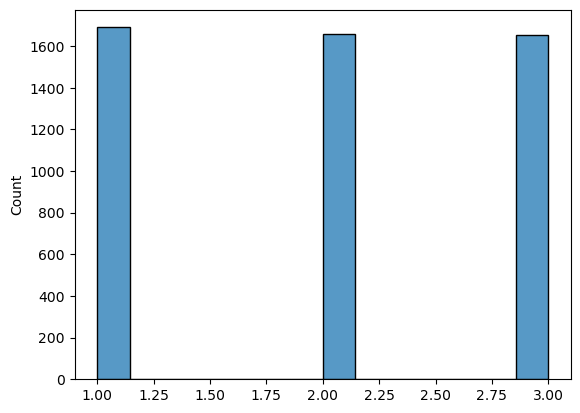

In [45]:
sns.histplot(test_dataset["count_min"])

In [46]:
def data_loader(dataset):
    """Converts dataset dict to padded tensors + lengths + proper targets.

    Returns:
      x: FloatTensor (batch, max_seq_len, n_objects)
      lengths: LongTensor (batch,) actual lengths for each sequence
      y: LongTensor (batch,) for multi-class (class indices 0..C-1)
         FloatTensor (batch,1) for binary/regression (normalized scalar)
    """
    seqs = []
    lengths = []
    targets = []

    for i in range(len(dataset["obj_sequence"])):
        obj_seq = np.array(dataset["obj_sequence"][i], dtype=np.int64)
        count_min = dataset["count_min"][i]   # assumed 1-based in your code earlier
        seqs.append(obj_seq)
        lengths.append(len(obj_seq))
        # For multi-class we will store target as class index (0..C-1)
        if dataset["n_classes"] > 2:
            # you previously did count_min - 1 when making one-hot; preserve that mapping:
            targets.append(int(count_min - 1))
        else:
            # binary/regression: normalize by seq length to keep target in [0,1]
            targets.append(float(count_min / len(obj_seq)))

    # Pad sequences to max length
    maxL = max(lengths)
    batch_size = len(seqs)
    n_objects = dataset["n_objects"]
    x = np.zeros((batch_size, maxL, n_objects), dtype=np.float32)
    for i, seq in enumerate(seqs):
        # one-hot encoding each timestep
        t = np.zeros((len(seq), n_objects), dtype=np.float32)
        t[np.arange(len(seq)), seq] = 1.0
        x[i, :len(seq), :] = t

    x = torch.from_numpy(x)                           # float32
    lengths = torch.tensor(lengths, dtype=torch.long) 

    if dataset["n_classes"] > 2:
        y = torch.tensor(targets, dtype=torch.long)  # for CrossEntropyLoss
    else:
        y = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)  # (batch,1) for BCE/regression

    return x, lengths, y

In [47]:
# 4) your existing loader works unchanged
x_train, len_train, y_train = data_loader(training_dataset)
x_test,  len_test,  y_test  = data_loader(test_dataset)

In [51]:
y_train[:20]

tensor([0, 2, 2, 1, 0, 2, 0, 2, 0, 0, 2, 2, 2, 1, 1, 2, 1, 0, 0, 2])

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np


class CountMinRNN(nn.Module):
    """
    RNN that accepts one-hot vectors of length input_size and maps to output_size.
    - If output_size > 2: multi-class logits -> use CrossEntropyLoss on last_out
    - If output_size == 1: binary/regression -> use BCEWithLogitsLoss on last_out
    """
    def __init__(self, input_size=8, output_size=1, hidden_size=16, num_layers=1, rnn_type='rnn', activation='sigmoid'):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size

        if rnn_type.lower() == 'gru':
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        elif rnn_type.lower() == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size, hidden_size, num_layers, nonlinearity='tanh', batch_first=True)

        # Map hidden state to output_size units (logits)
        self.output = nn.Linear(hidden_size, output_size)

        # Activation used only when you want a probability output (we will NOT apply it before CrossEntropy)
        if activation == 'sigmoid':
            self.act = nn.Sigmoid()
        elif activation == 'tanh':
            self.act = nn.Tanh()
        elif activation == 'identity' or activation is None:
            self.act = nn.Identity()
        else:
            raise ValueError("Unsupported activation")

    def forward(self, x, lengths=None, hx=None):
        """
        x: (B, T, input_size)
        lengths: (B,) real lengths (<= T)
        returns:
          out_seq: (B, T, output_size) -- logits for every timestep (padded positions are arbitrary)
          last_logits: (B, output_size)  -- logits at the real final timestep for each sequence
        """
        if lengths is not None:
            # pack + run RNN then pad back to (B, T, H)
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
            packed_out, h_n = self.rnn(packed, hx)
            rnn_out_padded, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
            # rnn_out_padded: (B, T, H) where T == max(lengths)
        else:
            rnn_out_padded, h_n = self.rnn(x, hx)  # (B, T, H)

        out_seq = self.output(rnn_out_padded)  # (B, T, output_size)

        if lengths is not None:
            # select the logits at the last real timestep for each batch element
            batch_idx = torch.arange(out_seq.size(0), device=out_seq.device)
            time_idx = (lengths - 1).to(device=out_seq.device)  # (B,)
            last_logits = out_seq[batch_idx, time_idx, :]       # (B, output_size)
        else:
            # if no lengths provided, take the very last timestep (index -1)
            last_logits = out_seq[:, -1, :]

        return out_seq, last_logits, rnn_out_padded


In [33]:
from copy import deepcopy
# Build loaders
x_train, lengths_train, y_train = data_loader(training_dataset)
x_test, lengths_test, y_test = data_loader(test_dataset)

# -----------------------
# Training setup
# -----------------------
device = "cpu"#torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = training_dataset["n_objects"]
output_size = training_dataset["n_classes"] if training_dataset["n_classes"] > 2 else 1
hidden_size = 32
num_layers = 1
lr = 0.01
epochs = 300
save_every = 1 # epochs

model = CountMinRNN(input_size=input_size, output_size=output_size,
                    hidden_size=hidden_size, num_layers=num_layers,
                    rnn_type='rnn', activation='sigmoid').to(device)
init_weights = {}
print("\nModel parameter summary (name, shape, L2 norm):")
for name, p in model.named_parameters():
    print(f"{name} {tuple(p.shape)}  L2={p.detach().cpu().norm().item():.4f}")
    init_weights[name] = p.detach().cpu().clone()

# Choose loss according to output type
if output_size > 1:
    criterion = nn.CrossEntropyLoss()   # expects logits (B, C) and y (B,) long
else:
    # Binary: use BCEWithLogits for numerical stability (expects logits and float target)
    criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=lr)


# Move data to device (this example uses full-batch training like your original)
x_train = x_train.to(device)
lengths_train = lengths_train.to(device)
y_train = y_train.to(device)

x_test = x_test.to(device)
lengths_test = lengths_test.to(device)
y_test = y_test.to(device)

# -----------------------
# Training loop
# -----------------------
# intialize place holder for results
train_results ={
    'epoch': [],
    'loss': [],
    'acc': [],
    'hidden_activations': []
}
test_results ={
    'epoch': [],
    'loss': [],
    'acc': [],
    'hidden_activations': []
}

for ep in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    out_seq, last_logits, hidden_seq = model(x_train, lengths_train)   # (B, C) or (B, 1)

    if output_size > 1:
        # y_train is (B,) long
        loss = criterion(last_logits, y_train)
        preds = torch.argmax(last_logits, dim=1)
        true = y_train
    else:
        # logits: (B,1), y_train: (B,1)
        loss = criterion(last_logits, y_train)
        probs = torch.sigmoid(last_logits)
        preds = (probs > 0.5).long().squeeze(1)
        true = y_train.long().squeeze(1)

    loss.backward()
    optimizer.step()

    # metrics
    with torch.no_grad():
        # train accuracy
        train_acc = (preds == true).float().mean().item()

        # test evaluation
        model.eval()
        out_seq_t, last_logits_t, hidden_seq_t = model(x_test, lengths_test)
        if output_size > 1:
            loss_t = criterion(last_logits_t, y_test)
            preds_test = torch.argmax(last_logits_t, dim=1)
            true_test = y_test
        else:
            loss_t = criterion(last_logits_t, y_test)
            probs_test = torch.sigmoid(last_logits_t)
            preds_test = (probs_test > 0.5).long().squeeze(1)
            true_test = y_test.long().squeeze(1)
        test_acc = (preds_test == true_test).float().mean().item()

    # logging
    if ep == 1 or ep % 10 == 0:
        print(f"Epoch {ep:3d}  Loss: {loss.item():.6f}  Train acc: {train_acc*100:.2f}%  Test acc: {test_acc*100:.2f}%")
    # save activations
    if ep % save_every == 0:
        train_results['epoch'].append(ep)
        train_results['loss'].append(loss.item())
        train_results['acc'].append(train_acc)
        train_results['hidden_activations'].append(hidden_seq.detach().cpu().numpy())
        test_results['epoch'].append(ep)
        test_results['loss'].append(loss_t.item())
        test_results['acc'].append(test_acc)
        test_results['hidden_activations'].append(hidden_seq_t.detach().cpu().numpy())




Model parameter summary (name, shape, L2 norm):
rnn.weight_ih_l0 (32, 8)  L2=1.6095
rnn.weight_hh_l0 (32, 32)  L2=3.2542
rnn.bias_ih_l0 (32,)  L2=0.5493
rnn.bias_hh_l0 (32,)  L2=0.5786
output.weight (3, 32)  L2=1.0263
output.bias (3,)  L2=0.2046
Epoch   1  Loss: 1.115205  Train acc: 33.27%  Test acc: 33.58%
Epoch  10  Loss: 1.098400  Train acc: 32.91%  Test acc: 33.98%
Epoch  20  Loss: 1.098210  Train acc: 33.20%  Test acc: 32.16%
Epoch  30  Loss: 1.097646  Train acc: 35.40%  Test acc: 32.56%
Epoch  40  Loss: 1.093150  Train acc: 36.84%  Test acc: 33.54%
Epoch  50  Loss: 1.001443  Train acc: 48.17%  Test acc: 44.22%
Epoch  60  Loss: 0.905389  Train acc: 59.00%  Test acc: 46.00%
Epoch  70  Loss: 0.836964  Train acc: 60.89%  Test acc: 48.14%
Epoch  80  Loss: 0.776202  Train acc: 63.36%  Test acc: 50.64%
Epoch  90  Loss: 0.708265  Train acc: 67.15%  Test acc: 51.46%
Epoch 100  Loss: 0.660922  Train acc: 69.78%  Test acc: 50.12%
Epoch 110  Loss: 0.568618  Train acc: 75.21%  Test acc: 53.4

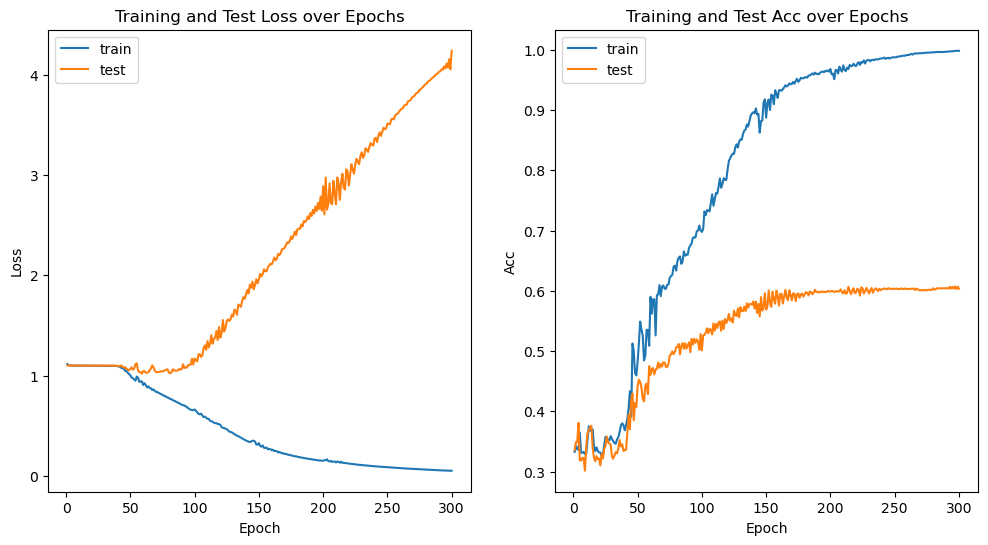

In [52]:
# plot training and test loss curves and accuracy curves
fig_perf,axes_perf = plt.subplots(1,2, figsize=(12,6))
for i, key in enumerate(['loss','acc']):
    axes_perf[i].plot(train_results['epoch'], train_results[key], label='train')
    axes_perf[i].plot(test_results['epoch'], test_results[key], label='test')
    axes_perf[i].set_xlabel('Epoch')
    axes_perf[i].set_ylabel(key.capitalize())
    axes_perf[i].set_title(f'Training and Test {key.capitalize()} over Epochs')
    axes_perf[i].legend()


In [53]:
# ------------------------
# After training: inspect learned weights (quick print)
# ------------------------
model_weights = {}
print("\nModel parameter summary (name, shape, L2 norm):")
for name, p in model.named_parameters():
    print(f"{name} {tuple(p.shape)}  L2={p.detach().cpu().norm().item():.4f}")
    model_weights[name] = p.detach().cpu().numpy()




Model parameter summary (name, shape, L2 norm):
rnn.weight_ih_l0 (32, 8)  L2=9.8979
rnn.weight_hh_l0 (32, 32)  L2=8.0189
rnn.bias_ih_l0 (32,)  L2=0.8281
rnn.bias_hh_l0 (32,)  L2=0.8380
output.weight (3, 32)  L2=9.2778
output.bias (3,)  L2=1.4588


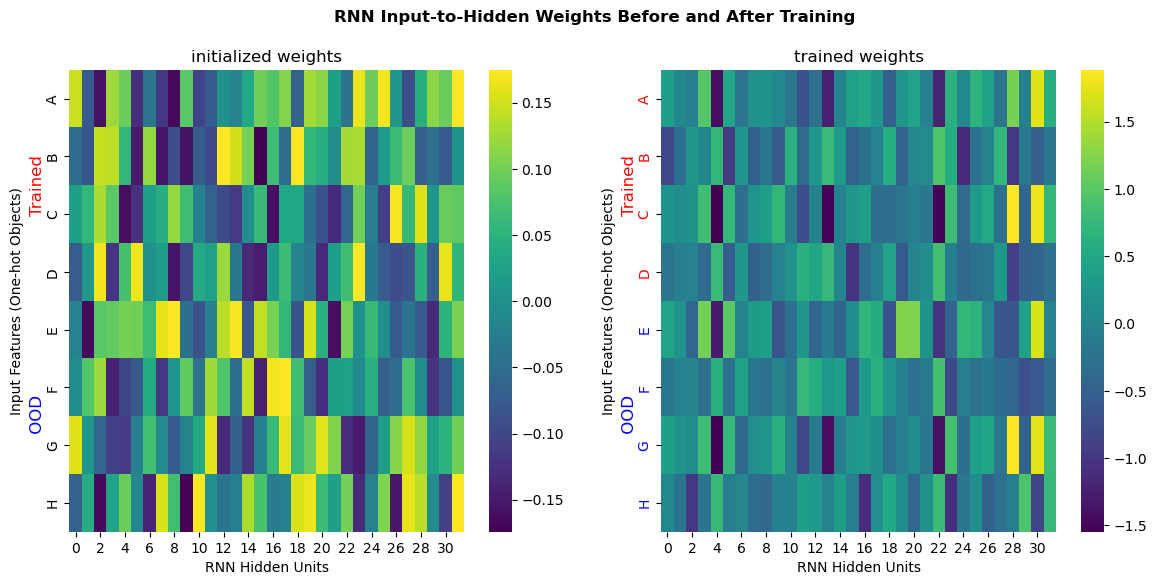

In [54]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
for i, (mname,mw) in enumerate(zip(["initialized weights", "trained weights"],[init_weights, model_weights])):
    ax = axes[i]
    sns.heatmap(mw['rnn.weight_ih_l0'].T, cmap='viridis',
                yticklabels=['A','B','C','D','E','F','G','H'],
                ax = ax)
    ax.set_xlabel('RNN Hidden Units')
    ax.set_ylabel('Input Features (One-hot Objects)\n  ')
    ax.set_title(mname)
    # Color each y-tick label
    for ticklabel, color in zip(plt.gca().get_yticklabels(), ['red']*4 + ['blue']*4):
        ticklabel.set_color(color)
    ax.text(-0.08, 0.75, 'Trained', color='red', fontsize=12,
            ha='center', va='center', rotation='vertical', transform=ax.transAxes)
    ax.text(-0.08, 0.25, ' OOD', color='blue', fontsize=12,
            ha='center', va='center', rotation='vertical', transform=ax.transAxes)

fig.suptitle('RNN Input-to-Hidden Weights Before and After Training', fontsize=12, weight='bold')
plt.show()


In [29]:
[x.shape for x in train_results['hidden_activations']]

[(50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32),
 (50000, 7, 32

In [78]:
# look at the activations
import tensortools as tt
ensemble = tt.Ensemble(fit_method="ncp_hals")
from sklearn.metrics import r2_score
# do in cv
X = train_results['hidden_activations'][-1].copy().T
ensemble.fit(X, ranks=range(1,10), replicates=1)


Rank-1 models:  min obj, 0.93;  max obj, 0.93;  time to fit, 2.6s


Rank-2 models:  min obj, 0.89;  max obj, 0.89;  time to fit, 5.9s


Rank-3 models:  min obj, 0.85;  max obj, 0.85;  time to fit, 3.7s


Rank-4 models:  min obj, 0.84;  max obj, 0.84;  time to fit, 3.6s


Rank-5 models:  min obj, 0.82;  max obj, 0.82;  time to fit, 4.0s


Rank-6 models:  min obj, 0.82;  max obj, 0.82;  time to fit, 2.8s


Rank-7 models:  min obj, 0.81;  max obj, 0.81;  time to fit, 6.9s


Rank-8 models:  min obj, 0.80;  max obj, 0.80;  time to fit, 4.7s


Rank-9 models:  min obj, 0.80;  max obj, 0.80;  time to fit, 9.0s


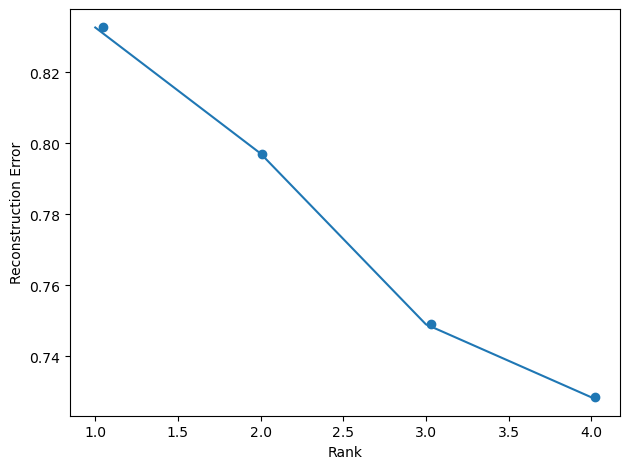

<Figure size 640x480 with 0 Axes>

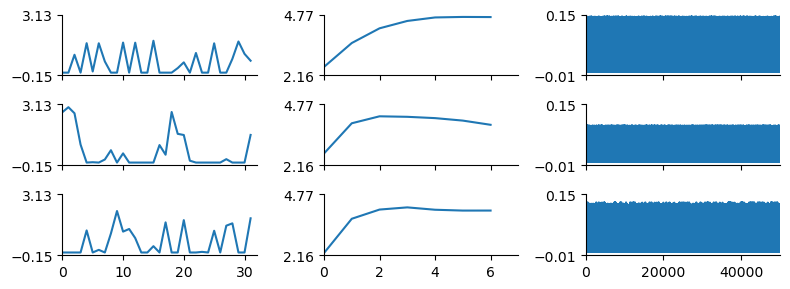

In [34]:
fig,ax = plt.subplots(1,1)
tt.plot_objective(ensemble, ax=ax)
ax.set_xlabel('Rank')
ax.set_ylabel('Reconstruction Error')
fig.tight_layout()

plt.figure()
num_components = 3
replicate = 0
tt.plot_factors(ensemble.factors(num_components)[replicate])
plt.show()

In [ ]:
# -----------------------
# Quick inference / prints
# -----------------------
model.eval()
with torch.no_grad():
    out_seq_t, last_logits_t, hidden_seq_t = model(x_test, lengths_test)
    if output_size > 1:
        preds = torch.argmax(last_logits_t, dim=1).cpu().numpy()
        print("Predicted class indices:", preds)
        print("True class indices:     ", y_test.cpu().numpy())
    else:
        probs = torch.sigmoid(last_logits_t).cpu().numpy().squeeze(1)
        print("Pred probs:", probs)
        print("True vals: ", y_test.cpu().numpy().squeeze(1))

[[Parameter containing:
  tensor([[ 5.6488e-02,  9.8758e-02,  5.6370e-01, -7.4556e-01,  1.1178e-01,
           -1.5846e-01,  1.3576e-01,  6.0528e-02],
          [ 1.8528e-01, -3.4675e-01, -8.5682e-01,  1.3798e+00, -7.5921e-02,
            1.7505e-01, -1.6728e-01,  9.7547e-02],
          [-6.1938e-01,  5.3570e-01,  1.1939e-01, -2.9405e-01,  1.6147e-01,
            3.6416e-02,  4.4491e-02,  1.6439e-01],
          [-8.5339e-01, -9.3008e-01,  9.2717e-01,  1.2940e+00, -1.6887e-01,
            1.6983e-01,  7.8512e-02, -1.7224e-03],
          [ 5.2254e-02, -3.7202e-01, -1.6705e-01,  4.6295e-02, -2.3974e-02,
            1.5877e-02, -1.0723e-02, -1.2611e-01],
          [-1.3212e-01, -1.3497e-01,  8.3676e-02,  2.4054e-01, -1.0916e-01,
            1.6823e-01, -8.1076e-02,  1.0674e-01],
          [-2.4917e-01,  7.3439e-01, -5.6028e-01,  1.0987e+00, -1.2318e-01,
           -3.9044e-02, -1.1682e-01,  1.1489e-01],
          [ 6.2529e-01, -5.0100e-02, -7.7792e-03, -2.5394e-01, -5.9315e-02,
           